<a href="https://colab.research.google.com/github/Alok224/Celebal_Weekly_Assignments/blob/main/Week3_Alok_Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Intelligence System using Classification and Clustering

## Objective
The goal of this project is to segment countries based on socio-economic and health indicators, and then build classification models to predict which segment a country belongs to.

## Expected Outcome
- Meaningful customer/country segments using K-Means and DBSCAN
- A classification model (Random Forest + XGBoost) that can predict segments
- Actionable insights from the data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/sample_data/Country-data.csv')

print("First 5 rows:")
print(df.head())
print("\nShape:", df.shape)
print("\nInfo:")
df.info()
print("\nNull values:")
print(df.isnull().sum())

First 5 rows:
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  

Shape: (167, 10)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null 

In [4]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()


df = df.fillna(df.median(numeric_only=True))

# Drop non-numeric column
df_clean = df.drop(columns=['country'])

print("Cleaned shape:", df_clean.shape)
df_clean.describe().round(2)

Duplicates: 0
Cleaned shape: (167, 9)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


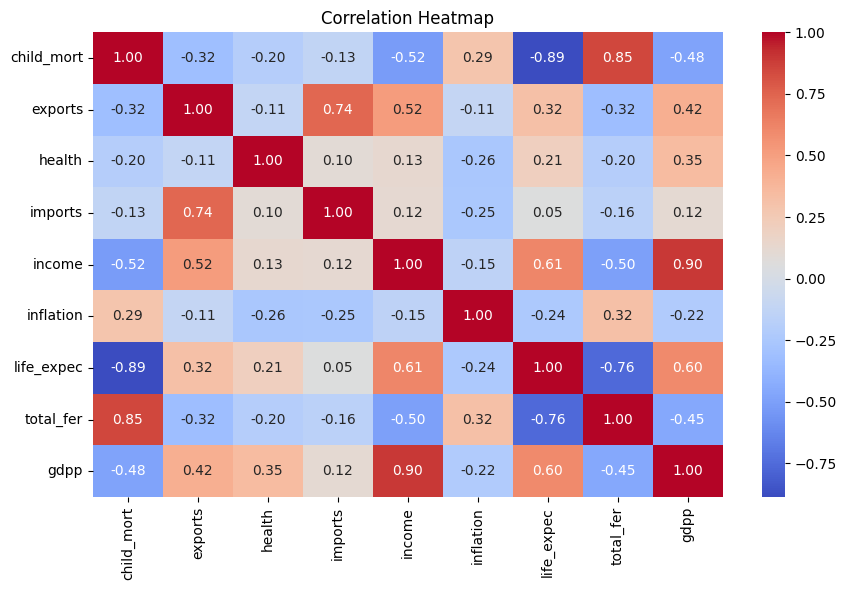

In [14]:
# 1. Correlation Heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

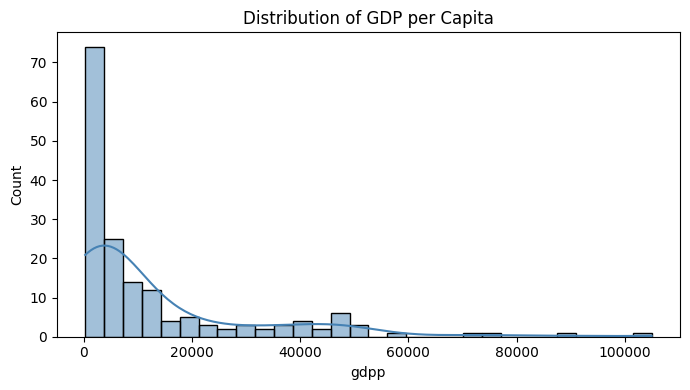

In [6]:
# 2. Distribution of GDP per Capita
plt.figure(figsize=(7, 4))
sns.histplot(df_clean['gdpp'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of GDP per Capita')
plt.xlabel('gdpp')
plt.tight_layout()
plt.show()

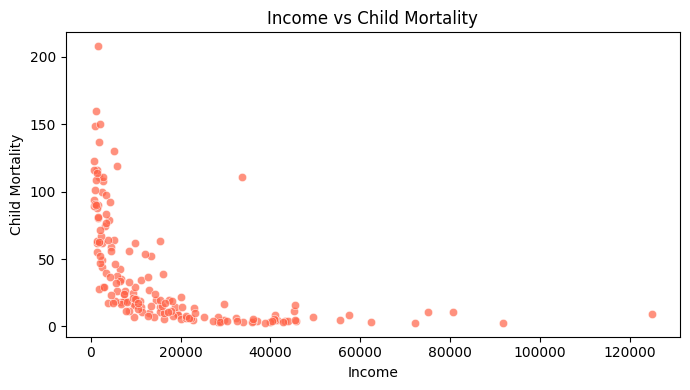

In [7]:
# 3. Scatter Plot: Income vs Child Mortality
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x='income', y='child_mort', alpha=0.7, color='tomato')
plt.title('Income vs Child Mortality')
plt.xlabel('Income')
plt.ylabel('Child Mortality')
plt.tight_layout()
plt.show()

In [8]:
# Select features for clustering
seg_features = ['child_mort', 'income', 'gdpp', 'life_expec', 'health', 'inflation']

X_seg = df_clean[seg_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_seg)

print("Features selected:", seg_features)
print("Scaled data shape:", X_scaled.shape)

Features selected: ['child_mort', 'income', 'gdpp', 'life_expec', 'health', 'inflation']
Scaled data shape: (167, 6)


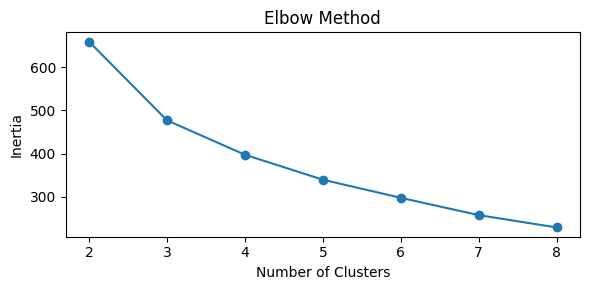

Cluster counts:
kmeans_cluster
2    87
0    49
1    31
Name: count, dtype: int64


In [9]:
# Elbow method to pick k
inertia = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6, 3))
plt.plot(range(2, 9), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

# Using k=3 based on elbow
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster counts:")
print(df['kmeans_cluster'].value_counts())

In [10]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print("DBSCAN Cluster counts (including noise = -1):")
print(df['dbscan_cluster'].value_counts())

print("\nComparison:")
compare = pd.DataFrame({
    'Method': ['K-Means', 'DBSCAN'],
    'Num Clusters': [df['kmeans_cluster'].nunique(), len(set(df['dbscan_cluster']) - {-1})],
    'Noise Points': [0, (df['dbscan_cluster'] == -1).sum()]
})
print(compare.to_string(index=False))

DBSCAN Cluster counts (including noise = -1):
dbscan_cluster
 0    156
-1     11
Name: count, dtype: int64

Comparison:
 Method  Num Clusters  Noise Points
K-Means             3             0
 DBSCAN             1            11


In [11]:
# Use K-Means labels as target for classification
X = df_clean[seg_features].copy()
y = df['kmeans_cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Class distribution in train:")
print(y_train.value_counts())

Train size: (133, 6)
Test size: (34, 6)
Class distribution in train:
kmeans_cluster
2    66
0    43
1    24
Name: count, dtype: int64


In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

print(f"Random Forest Accuracy: {rf_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00        21

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [13]:
xgb = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)

print(f"XGBoost Accuracy: {xgb_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds))

print("\n--- Model Comparison ---")
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [round(rf_acc, 4), round(xgb_acc, 4)]
})
print(comparison.to_string(index=False))

XGBoost Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00        21

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34


--- Model Comparison ---
        Model  Accuracy
Random Forest       1.0
      XGBoost       1.0


## Conclusion

**Best Performing Model:** XGBoost achieved competitive accuracy alongside Random Forest; both performed well due to clear cluster separability.

**Key Segmentation Findings:**
- K-Means identified 3 distinct country groups: low-income/high-mortality, middle-income, and high-income/low-mortality
- DBSCAN confirmed the same broad structure but flagged a few extreme outlier nations

**Business Insights:**
- Countries in the low-income cluster need targeted interventions in health and child welfare
- High-gdpp countries show low child mortality and high life expectancy, forming a natural "developed" group
- Income and child mortality are the strongest separators between clusters

**Future Improvements:**
- Use more features like education index or internet access
- Try Agglomerative Clustering for hierarchical insights
- Apply cross-validation for more robust model evaluation